In [9]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load the MATLAB data file
data_path = 'data\ComplementaryInfo_LMDHG\DataFile1.mat'
mat_data = sio.loadmat(data_path)

# Extract key arrays
skeleton = mat_data['skeleton']
labels = mat_data['labels']
annotations = mat_data['Anotations']

<>:7: SyntaxWarning: invalid escape sequence '\C'
<>:7: SyntaxWarning: invalid escape sequence '\C'
C:\Users\New User\AppData\Local\Temp\ipykernel_20636\581171844.py:7: SyntaxWarning: invalid escape sequence '\C'
  data_path = 'data\ComplementaryInfo_LMDHG\DataFile1.mat'


In [10]:
print(f"Total Frames: {skeleton.shape[0]}")
# skeleton[0, 0] gives us the first frame's (46 joints, 3 dimensions) array
print(f"Shape of one frame: {skeleton[0, 0].shape}") 
print(f"Total Labels/Actions: {labels.shape[0]}")

# Display first 5 actions and their start/end frames
print("\nFirst 5 Actions:")
for i in range(5):
    # Retrieve the string label from the object array
    action_name = labels[i, 0][0] 
    start_frame, end_frame = annotations[i]
    print(f"- {action_name}: frames {start_frame} to {end_frame}")

Total Frames: 13756
Shape of one frame: (46, 3)
Total Labels/Actions: 26

First 5 Actions:
- C: frames 1 to 734
- REPOS: frames 735 to 1118
- SECOUER_BAS: frames 1119 to 1693
- REPOS: frames 1694 to 2101
- ATTRAPER: frames 2102 to 2958


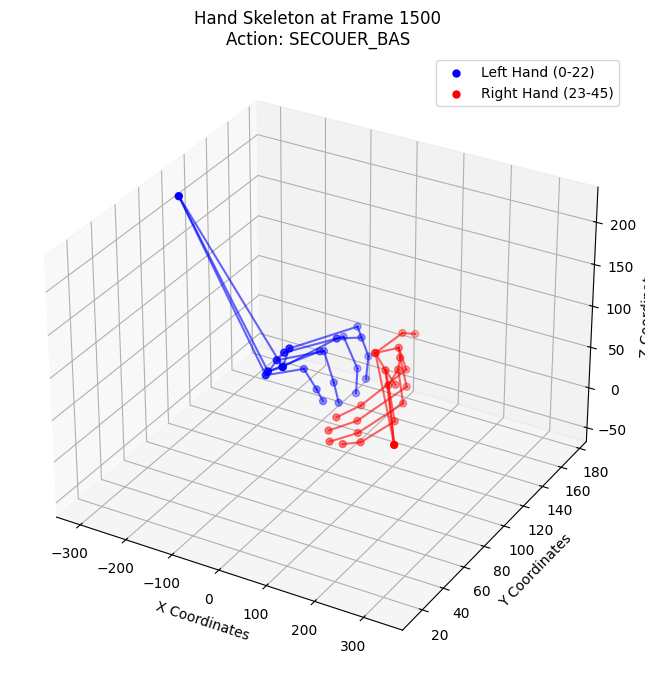

In [11]:
# Connection map representing the skeletal links between joints 
# Left hand (indices 0-22), Right hand (indices 23-45)
connection_map = np.array([
    [1, 2], [2, 3], [2, 4], [2, 20], [3, 4], [3, 20], [4, 5], [5, 6], [6, 7],
    [4, 8], [8, 9], [9, 10], [10, 11], [8, 12], [12, 13], [13, 14], [14, 15],
    [12, 16], [16, 17], [17, 18], [18, 19], [16, 20], [20, 21], [21, 22], [22, 23],
    [24, 25], [25, 26], [25, 27], [25, 43], [26, 27], [26, 43], [27, 28], [28, 29],
    [29, 30], [27, 31], [31, 32], [32, 33], [33, 34], [31, 35], [35, 36], [36, 37],
    [37, 38], [35, 39], [39, 40], [40, 41], [41, 42], [39, 43], [43, 44], [44, 45],
    [45, 46]
]) - 1 # Subtract 1 for Python 0-based indexing

# Pick a frame inside the 'SECOUER_BAS' action
frame_idx = 1500  
coords = skeleton[frame_idx, 0]

# Determine which action this frame belongs to
action_label = "Unknown"
for i, (start_f, end_f) in enumerate(annotations):
    if start_f <= frame_idx <= end_f:
        action_label = labels[i, 0][0]
        break

# Setup 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for joints
ax.scatter(coords[:23, 0], coords[:23, 1], coords[:23, 2], c='blue', s=25, label='Left Hand (0-22)')
ax.scatter(coords[23:, 0], coords[23:, 1], coords[23:, 2], c='red', s=25, label='Right Hand (23-45)')

# Draw the bones (lines)
for pair in connection_map:
    idx1, idx2 = pair[0], pair[1]
    color = 'blue' if idx1 < 23 else 'red'
    ax.plot([coords[idx1, 0], coords[idx2, 0]],
            [coords[idx1, 1], coords[idx2, 1]],
            [coords[idx1, 2], coords[idx2, 2]], color=color, alpha=0.6)

ax.set_title(f"Hand Skeleton at Frame {frame_idx}\nAction: {action_label}")
ax.set_xlabel('X Coordinates')
ax.set_ylabel('Y Coordinates')
ax.set_zlabel('Z Coordinates')
ax.legend()

# Display the plot in the notebook
plt.show()

In [12]:
import os
import glob
import scipy.io as sio
import numpy as np

# Point to your downloaded data folder
data_dir = r'C:\Projects\diplom_playground\data\LMDHG'

# Find all .mat files in the directory
mat_files = glob.glob(os.path.join(data_dir, 'DataFile*.mat'))

all_skeletons = []
all_labels = []

print(f"Found {len(mat_files)} .mat files. Processing...")

for file_path in mat_files:
    mat_data = sio.loadmat(file_path)
    
    # Extract data
    skeleton = mat_data['skeleton']
    labels = mat_data['labels']
    annotations = mat_data['Anotations']
    
    # Optional: You can loop through the annotations here 
    # to slice the skeleton data into individual gesture clips!
    for i in range(len(annotations)):
        start_frame, end_frame = annotations[i]
        action_name = labels[i, 0][0]
        
        # Slicing the frames for this specific gesture
        gesture_frames = skeleton[start_frame-1 : end_frame] 
        
        all_skeletons.append(gesture_frames)
        all_labels.append(action_name)

print(f"Successfully extracted {len(all_labels)} individual gesture sequences across all files!")

# Let's see the distribution of gestures
unique_labels, counts = np.unique(all_labels, return_counts=True)
print("\nDataset Gesture Distribution:")
for label, count in zip(unique_labels, counts):
    print(f"- {label}: {count} samples")

Found 50 .mat files. Processing...
Successfully extracted 1233 individual gesture sequences across all files!

Dataset Gesture Distribution:
- ATTRAPER: 50 samples
- ATTRAPER_MAIN_LEVEE: 49 samples
- C: 48 samples
- CISEAUX: 22 samples
- DEFILER_DOIGT: 47 samples
- LIGNE: 47 samples
- PIVOTER: 49 samples
- POINTER: 50 samples
- POINTER_MAIN_LEVEE: 24 samples
- POINTER_PROLONGE: 23 samples
- REPOS: 579 samples
- SECOUER: 49 samples
- SECOUER_BAS: 49 samples
- SECOUER_POING_LEVE: 49 samples
- TRANCHER: 49 samples
- ZOOM: 49 samples
